In [11]:
#============================================================
# TASK 4: Sales Prediction using Python — CodeAlpha
# 
# Description:
#   Predict sales based on advertising spend across TV, Radio,
#   and Newspaper channels. I apply regression models, analyze
#   feature impact, and provide business insights.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [7]:
# 1. LOAD & EXPLORE DATA

DATA_PATH = "Advertising.csv"

try:
    df = pd.read_csv(DATA_PATH)
    # Drop unnamed index column if present
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    print(f"\n Dataset loaded: {df.shape[0]} rows × {df.shape[1]} cols")
except FileNotFoundError:
    print("    Using the standard Advertising dataset (synthetic)...\n")
    np.random.seed(42)
    n = 200
    TV        = np.random.uniform(0.7, 296, n)
    Radio     = np.random.uniform(0.0, 49,  n)
    Newspaper = np.random.uniform(0.3, 114, n)
    Sales = (0.047 * TV + 0.185 * Radio + 0.003 * Newspaper
             + 7.0 + np.random.normal(0, 1.5, n))
    Sales = np.clip(Sales, 1.6, 30)
    df = pd.DataFrame({'TV': TV.round(1), 'Radio': Radio.round(1),
                       'Newspaper': Newspaper.round(1), 'Sales': Sales.round(1)})
    print(f"    Synthetic dataset created: {df.shape}\n")

print(f"\n Columns : {list(df.columns)}")
print(f"\n First 5 Rows:\n{df.head()}")
print(f"\n Statistical Summary:\n{df.describe().round(2)}")
print(f"\n Missing Values: {df.isnull().sum().sum()}")

target = 'Sales'
features = [c for c in df.columns if c != target]

    Using the standard Advertising dataset (synthetic)...

    Synthetic dataset created: (200, 4)


 Columns : ['TV', 'Radio', 'Newspaper', 'Sales']

 First 5 Rows:
      TV  Radio  Newspaper  Sales
0  111.3   31.5       12.0   17.3
1  281.4    4.1      102.9   20.1
2  216.9    7.9       57.7   18.7
3  177.5   44.0       94.3   22.2
4   46.8   29.7       36.7   14.0

 Statistical Summary:
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   143.63   24.71      59.50   18.41
std     87.08   14.36      34.94    4.96
min      2.30    0.20       1.50    5.40
25%     68.22   12.82      29.38   14.28
50%    146.70   26.55      60.05   18.70
75%    224.20   36.38      92.55   22.12
max    292.10   48.50     114.00   27.90

 Missing Values: 0


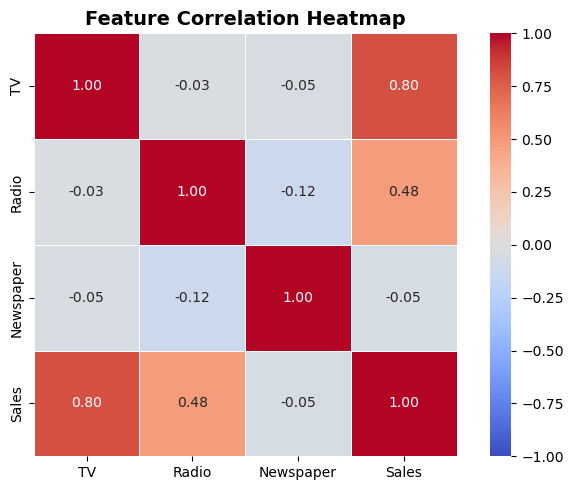


 Plot saved: sales_correlation.png


In [3]:
# --- 2a: Correlation Heatmap ---
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sales_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: sales_correlation.png")

In [8]:
# 3. FEATURE ENGINEERING

df_eng = df.copy()

# Interaction & ratio features
if 'TV' in features and 'Radio' in features:
    df_eng['TV_Radio_interact']  = df_eng['TV'] * df_eng['Radio']
    df_eng['TV_per_Radio']       = df_eng['TV'] / (df_eng['Radio'] + 1)
    df_eng['Total_Budget']       = df_eng[features].sum(axis=1)
    df_eng['TV_share']           = df_eng['TV'] / (df_eng['Total_Budget'] + 1)
    df_eng['Radio_share']        = df_eng['Radio'] / (df_eng['Total_Budget'] + 1)
    print(f"\n  New features added: TV_Radio_interact, TV_per_Radio, "
          f"Total_Budget, TV_share, Radio_share")

X = df_eng.drop(columns=[target])
y = df_eng[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n Train/Test Split: {X_train.shape[0]} train | {X_test.shape[0]} test")


  New features added: TV_Radio_interact, TV_per_Radio, Total_Budget, TV_share, Radio_share

 Train/Test Split: 160 train | 40 test


In [9]:
# 4. TRAIN & COMPARE MODELS

def evaluate_model(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return {
        "MAE":  mean_absolute_error(yte, preds),
        "RMSE": np.sqrt(mean_squared_error(yte, preds)),
        "R2":   r2_score(yte, preds),
        "preds": preds
    }

models = {
    "Linear Regression":     LinearRegression(),
    "Ridge (α=1)":           Ridge(alpha=1.0),
    "Lasso (α=0.1)":         Lasso(alpha=0.1),
    "Polynomial (deg=2)":    Pipeline([
                                 ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                                 ('lr',   LinearRegression())
                             ]),
    "Random Forest":         RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":     GradientBoostingRegressor(n_estimators=100, random_state=42),
}
results = {}

print("        MODEL COMPARISON RESULTS")

for name, model in models.items():
    res = evaluate_model(model, X_train_sc, X_test_sc, y_train, y_test)
    results[name] = res
    print(f"\n {name}")
    print(f"   MAE  : {res['MAE']:.4f}")
    print(f"   RMSE : {res['RMSE']:.4f}")
    print(f"   R²   : {res['R2']:.4f}")

        MODEL COMPARISON RESULTS

 Linear Regression
   MAE  : 1.1306
   RMSE : 1.3285
   R²   : 0.9274

 Ridge (α=1)
   MAE  : 1.1343
   RMSE : 1.3196
   R²   : 0.9284

 Lasso (α=0.1)
   MAE  : 1.1399
   RMSE : 1.3078
   R²   : 0.9297

 Polynomial (deg=2)
   MAE  : 1.2670
   RMSE : 1.5407
   R²   : 0.9024

 Random Forest
   MAE  : 1.4801
   RMSE : 1.7881
   R²   : 0.8686

 Gradient Boosting
   MAE  : 1.4850
   RMSE : 1.7164
   R²   : 0.8789


   BEST MODEL: Lasso (α=0.1)
  MAE  : 1.1399
  RMSE : 1.3078
  R²   : 0.9297 (92.97% variance explained)


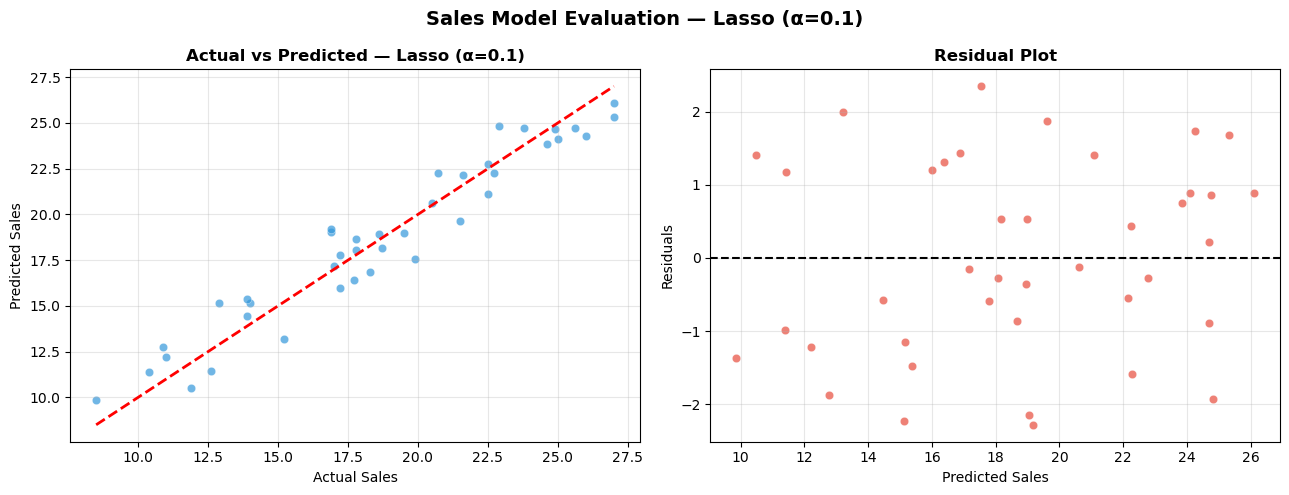


 Plot saved: sales_actual_vs_predicted.png


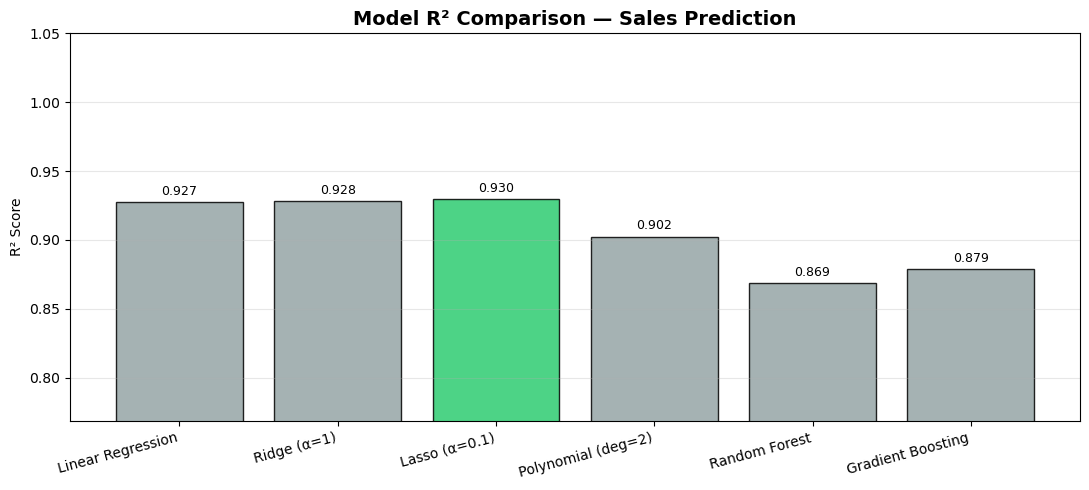

 Plot saved: sales_model_comparison.png


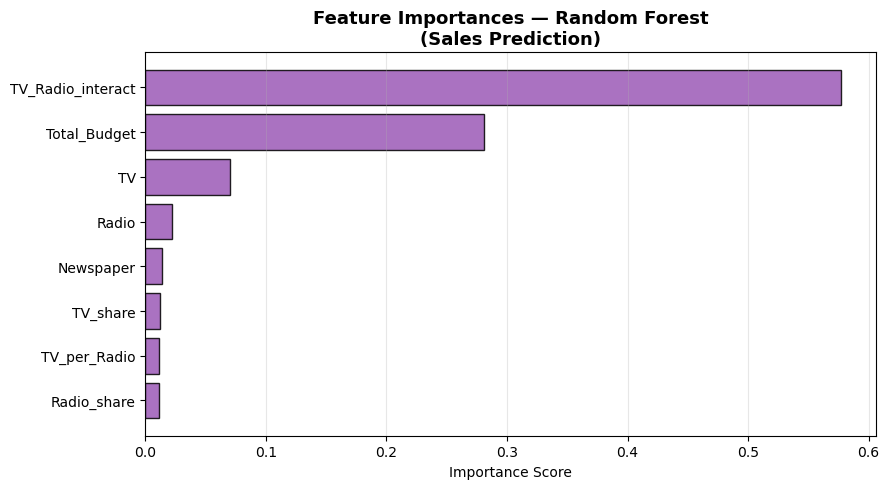

 Plot saved: sales_feature_importance.png


In [10]:
# 5. BEST MODEL ANALYSIS

best_name  = max(results, key=lambda k: results[k]['R2'])
best_res   = results[best_name]
best_preds = best_res['preds']


print(f"   BEST MODEL: {best_name}")

print(f"  MAE  : {best_res['MAE']:.4f}")
print(f"  RMSE : {best_res['RMSE']:.4f}")
print(f"  R²   : {best_res['R2']:.4f} ({best_res['R2']*100:.2f}% variance explained)")

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.7, color='#3498db',
                edgecolors='white', linewidths=0.3)
lo = min(y_test.min(), best_preds.min())
hi = max(y_test.max(), best_preds.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2)
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title(f"Actual vs Predicted — {best_name}", fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

residuals = y_test.values - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.7, color='#e74c3c',
                edgecolors='white', linewidths=0.3)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Predicted Sales")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot", fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle(f"Sales Model Evaluation — {best_name}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sales_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: sales_actual_vs_predicted.png")

# Model R² Comparison
fig, ax = plt.subplots(figsize=(11, 5))
names  = list(results.keys())
r2vals = [results[n]['R2'] for n in names]
colors = ['#2ecc71' if n == best_name else '#95a5a6' for n in names]
bars   = ax.bar(names, r2vals, color=colors, edgecolor='black', alpha=0.85)
ax.set_ylim(max(0, min(r2vals) - 0.1), 1.05)
ax.set_ylabel("R² Score")
ax.set_title("Model R² Comparison — Sales Prediction",
             fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.xticks(rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("sales_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved: sales_model_comparison.png")

# Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#9b59b6', edgecolor='black', alpha=0.85)
plt.title("Feature Importances — Random Forest\n(Sales Prediction)",
          fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("sales_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved: sales_feature_importance.png")

In [31]:
# 6. BUSINESS INSIGHTS — Budget Sensitivity

# Use Linear Regression coefficients for interpretability
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

base_cols = [c for c in ['TV', 'Radio', 'Newspaper'] if c in X.columns]
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print(f"\n  Linear Regression Coefficients (standardized):")
for _, row in coef_df[coef_df['Feature'].isin(base_cols)].iterrows():
    sign = ' ' if row['Coefficient'] > 0 else ' '
    print(f"  {row['Feature']:15s}: {row['Coefficient']:+.4f}")



print(f"\n   Key Takeaways:")
top_feat = coef_df[coef_df['Feature'].isin(base_cols)].iloc[0]
print(f"    '{top_feat['Feature']}' has the strongest positive impact on sales.")
print(f"     Increasing TV & Radio budgets yields the most return on investment.")
print(f"     Model explains {best_res['R2']*100:.1f}% of sales variance.")
print(f"     Average prediction error (MAE): {best_res['MAE']:.2f} units")

# What-if simulation
print("\n   What-if Simulation (Linear Model):")
scenarios = [
    {"TV": 100, "Radio": 20, "Newspaper": 10},
    {"TV": 200, "Radio": 40, "Newspaper": 20},
    {"TV": 50,  "Radio": 50, "Newspaper": 5},
]

for sc in scenarios:
    row = pd.DataFrame([sc])
    for col in X.columns:
        if col not in row.columns:
            row[col] = 0
    row = row[X.columns]
    row_sc   = scaler.transform(row)
    pred_val = lr.predict(row_sc)[0]
    print(f"    TV={sc['TV']:3d} | Radio={sc['Radio']:2d} | "
          f"Newspaper={sc['Newspaper']:2d}  →  Predicted Sales ≈ {pred_val:.1f} units")


  Linear Regression Coefficients (standardized):
  Radio          : +2.3667
  TV             : +2.0252
  Newspaper      : -0.3051

   Key Takeaways:
    'Radio' has the strongest positive impact on sales.
     Increasing TV & Radio budgets yields the most return on investment.
     Model explains 93.0% of sales variance.
     Average prediction error (MAE): 1.14 units

   What-if Simulation (Linear Model):
    TV=100 | Radio=20 | Newspaper=10  →  Predicted Sales ≈ 11.2 units
    TV=200 | Radio=40 | Newspaper=20  →  Predicted Sales ≈ 16.7 units
    TV= 50 | Radio=50 | Newspaper= 5  →  Predicted Sales ≈ 14.9 units
